## Exercice 1 

In [15]:
import pandas as pd 

gender_submission = pd.read_csv('gender_submission.csv')
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')

#Identifiez les lignes en double en vous basant sur toutes les colonnes.
verif_train = train.duplicated()
verif_test = test.duplicated()
verif_gender_submission = gender_submission.duplicated()

# Affichez le nombre de doublons avant suppression 
print(verif_train.sum())
print(verif_test.sum())
print(verif_gender_submission.sum())

#Sauvegarde des tailles avant suppression pour comparaison
n_train_before = train.shape[0]
n_test_before = test.shape[0]
n_gender_before = gender_submission.shape[0]

#Supprimez les lignes en double présentes dans l'ensemble de données.
train = train.drop_duplicates()
test = test.drop_duplicates()
gender_submission = gender_submission.drop_duplicates()

#Vérifiez la suppression des doublons en comparant le nombre de lignes avant et après la suppression.
n_train_after = train.shape[0]
n_test_after = test.shape[0]
n_gender_after = gender_submission.shape[0]

# Optionnel : vérification finale du nombre de doublons (doit être 0)
print(train.duplicated().sum())
print(test.duplicated().sum())
print(gender_submission.duplicated().sum())

0
0
0
0
0
0


## Exercice 2

In [16]:
import pandas as pd

# Exercice 2: Gestion des valeurs manquantes sur le dataframe principal train
print("Valeurs manquantes AVANT traitement:")
print(train[["Age", "Embarked", "Fare"]].isnull().sum())

# 1) Suppression (démo sur une copie)
train_suppression = train.dropna()
print("Lignes train avant/apres dropna:", train.shape[0], train_suppression.shape[0])

# 2) Imputation moyenne pour Age (numérique)
train["Age"] = train["Age"].fillna(train["Age"].mean())

# 3) Valeur constante pour Embarked (catégorielle)
train["Embarked"] = train["Embarked"].fillna("Unknown")

print("Valeurs manquantes APRES traitement:")
print(train[["Age", "Embarked", "Fare"]].isnull().sum())

Valeurs manquantes AVANT traitement:
Age         177
Embarked      2
Fare          0
dtype: int64
Lignes train avant/apres dropna: 891 183
Valeurs manquantes APRES traitement:
Age         0
Embarked    0
Fare        0
dtype: int64


## Exercice 3

In [17]:
from sklearn.preprocessing import LabelEncoder

# Exercice 3: Feature engineering + encodage simple
# 1) Nouvelle feature: taille de la famille
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

# 2) Extraire le titre depuis le nom
train["Title"] = train["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 3) Encoder Title (texte -> nombre)
le_title = LabelEncoder()
train["Title"] = le_title.fit_transform(train["Title"])

# 4) Encoder Sex en one-hot (une seule fois)
if "Sex" in train.columns:
    train = pd.get_dummies(train, columns=["Sex"], drop_first=True)

print(train[["FamilySize", "Title"]].head())

   FamilySize  Title
0           2     12
1           2     13
2           1      9
3           2     13
4           1     12


## Exercice 4  

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

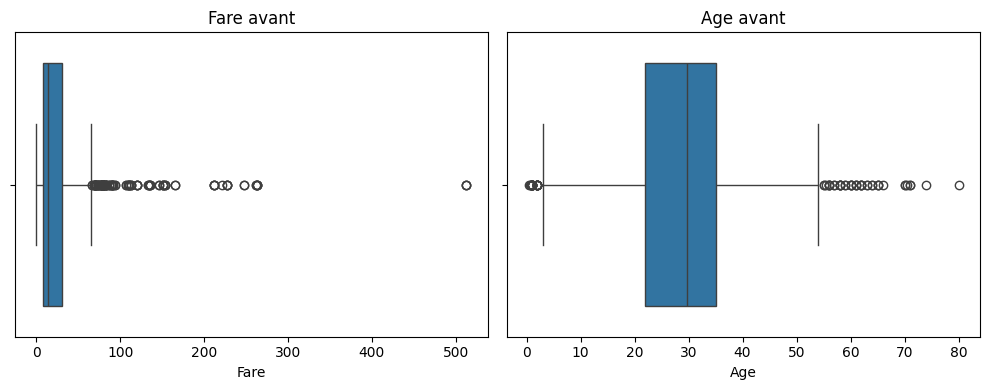

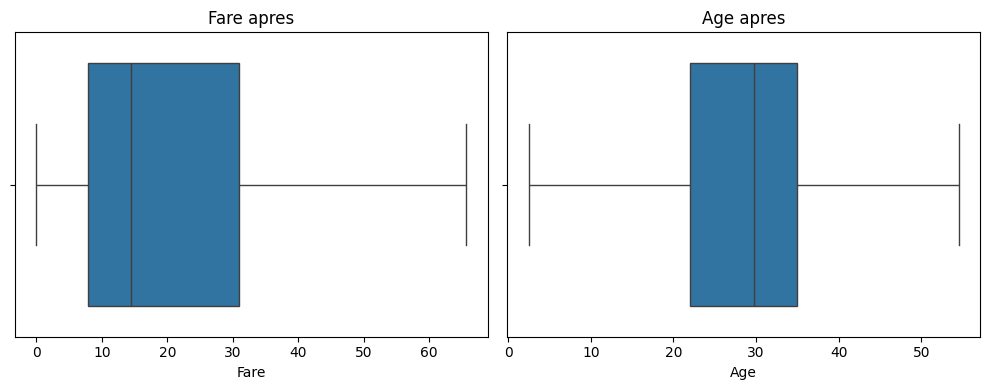

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Exercice 4: Gestion des valeurs aberrantes sur Fare ET Age
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=train["Fare"], ax=axes[0])
axes[0].set_title("Fare avant")
sns.boxplot(x=train["Age"], ax=axes[1])
axes[1].set_title("Age avant")
plt.tight_layout()
plt.show()

# Methode IQR sur Fare et Age
for col in ["Fare", "Age"]:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr

    # Capping simple (debutant): on limite aux bornes
    train[col] = train[col].clip(lower=borne_inf, upper=borne_sup)

# Transformation log pour Fare apres capping
train["Fare_log"] = np.log1p(train["Fare"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=train["Fare"], ax=axes[0])
axes[0].set_title("Fare apres")
sns.boxplot(x=train["Age"], ax=axes[1])
axes[1].set_title("Age apres")
plt.tight_layout()
plt.show()

## Exercice 5

In [19]:
# Importation des outils de mise a l'echelle
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Exercice 5: on conserve les colonnes originales et on cree des colonnes scalees
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

train["Age_scaled"] = standard_scaler.fit_transform(train[["Age"]])
train["Fare_scaled"] = minmax_scaler.fit_transform(train[["Fare"]])

print(train[["Age", "Age_scaled", "Fare", "Fare_scaled"]].head())

    Age  Age_scaled     Fare  Fare_scaled
0  22.0   -0.611917   7.2500     0.110460
1  38.0    0.715304  65.6344     1.000000
2  26.0   -0.280111   7.9250     0.120745
3  35.0    0.466450  53.1000     0.809027
4  35.0    0.466450   8.0500     0.122649


## Exercice 6

In [20]:
# Exercice 6: Encodage categoriel restant (sans doublon)
import pandas as pd

# Ici Sex et Title sont deja traites dans Exercice 3.
# On encode seulement Embarked si la colonne existe encore.
if "Embarked" in train.columns:
    train = pd.get_dummies(train, columns=["Embarked"], prefix="Embarked", drop_first=True)

print("Colonnes encodees presentes:")
print([col for col in train.columns if col.startswith("Embarked_") or col.startswith("Sex_") or col == "Title"])

Colonnes encodees presentes:
['Title', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Embarked_Unknown']


## Exercice 7

In [21]:
import pandas as pd

# Exercice 7: discretisation de Age (sur age non standardise)
# 0-12  -> Enfant
# 12-18 -> Adolescent
# 18-60 -> Adulte
# 60+   -> Senior

bins = [0, 12, 18, 60, 100]
labels = ["Enfant", "Adolescent", "Adulte", "Senior"]

train["Age_Group"] = pd.cut(
    train["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(train[["Age", "Age_Group"]].head())

# Encodage one-hot de la nouvelle variable categorielle
train = pd.get_dummies(train, columns=["Age_Group"], prefix="Age_Group", drop_first=True)

print([col for col in train.columns if col.startswith("Age_Group_")])

    Age Age_Group
0  22.0    Adulte
1  38.0    Adulte
2  26.0    Adulte
3  35.0    Adulte
4  35.0    Adulte
['Age_Group_Adolescent', 'Age_Group_Adulte', 'Age_Group_Senior']
